## Manual Trading Challenge 2 - IMC Prosperity

In [169]:
import numpy as np
import pandas as pd
from scipy.stats import beta
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

### 1. Problem and Approach

In [170]:
def research(pp):
    return 200000*np.log(1+pp*100) / np.log(101)

def scale(pp):
    return pp * 7

def speed(percentile):
    return percentile * 0.8 / 100 + 0.1

def pnl(pps:dict, percentile:float):
    if int(round(sum(pps.values()),0)) != 1: return 'Check weights'
    r = research(pps["research"])
    s = scale(pps["scale"])
    v = speed(percentile)
    return np.prod([r,s,v]) - 50000

### 2. Optimal Research and Scale Allocation

#### 2.1. Research-Scale Function

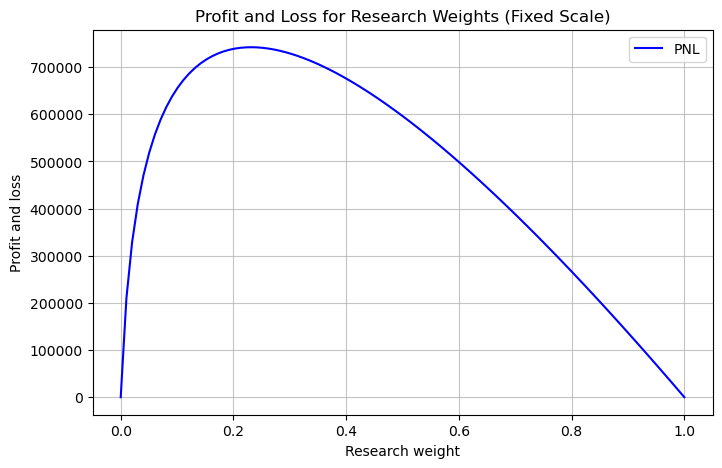

In [171]:
def rs_func(r, s):
    return (research(r) * scale(s))

r_vals = np.linspace(0, 1, 100)
s_vals = 1 - r_vals
z_vals = [rs_func(r, s) for r, s in zip(r_vals, s_vals)]

plt.figure(figsize=(8, 5))
plt.plot(r_vals, z_vals, label='PNL', color='blue')
plt.xlabel('Research weight')
plt.ylabel('Profit and loss')
plt.title('Profit and Loss for Research Weights (Fixed Scale)')
plt.legend()
plt.grid(alpha=0.75)
plt.show()

#### 2.2. Optimal Allocation

In [172]:
def optimal_rs_allocation():
    def objective(x):
        return - rs_func(*x)
    constraint = {'type': 'eq', 'fun': lambda x: sum(x) - 1}
    result = minimize(objective, [0.5,0.5], constraints=[constraint])
    return result.x, -result.fun  # Valeurs optimales et valeur max

(optimal_r, optimal_s), opt_pnl = optimal_rs_allocation()
print(f"Optimal Weight:\n   Research: {round(optimal_r,3)}\n   Scale: {round(optimal_s,3)}")
print(f"Resuling PNL: ${int(opt_pnl)}")

Optimal Weight:
   Research: 0.231
   Scale: 0.769
Resuling PNL: $742336


#### 2.3. Optimal Allocation for a Given Speed

In [173]:
def split(speed):
    return {
        "research": (1 - speed) * optimal_r,
        "scale": (1 - speed) * optimal_s,
        "speed": speed
    }

ex_split = list(split(0.3).values())
print("Example for speed=0.3:")
print(f"   Research: {round(ex_split[0],3)}\n   Scale: {round(ex_split[1],3)}\n   Scale: {round(ex_split[2],3)}")

Example for speed=0.3:
   Research: 0.162
   Scale: 0.538
   Scale: 0.3


### 3. Speed and Bet Distribution

#### 3.1. Worst Case Scenario

#### 3.2. Beta Distribution

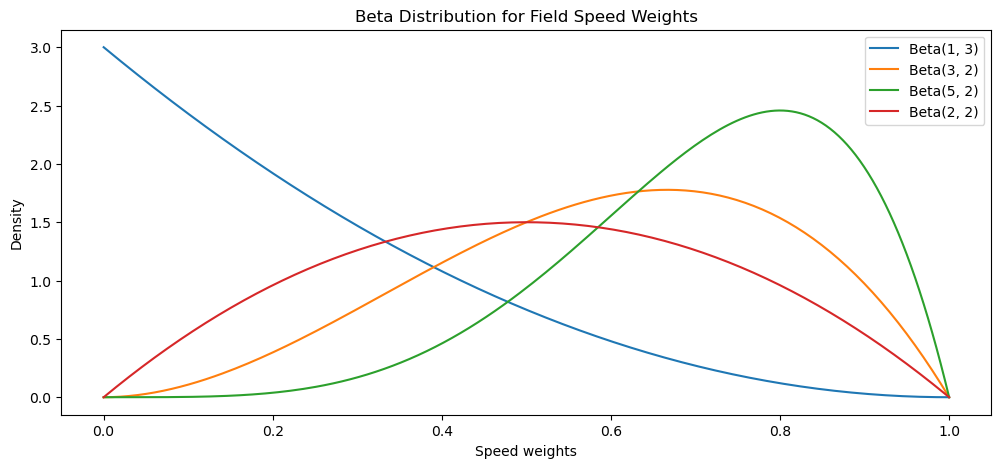

In [174]:
# Discret beta draws
def beta_draw(a, b, n=1):
    x = np.arange(0, 1.01, 0.01)
    probs = beta.pdf(x, a, b)
    probs = probs / probs.sum()
    return np.random.choice(x, size=n, p=probs)

ab_range = [(1,3), (3,2), (5,2), (2,2)]
x = np.linspace(0, 1, 200)
ybetas = [beta.pdf(x, a, b) for (a,b) in ab_range]

plt.figure(figsize=(12,5))
for i in range(len(ybetas)):
    plt.plot(x, ybetas[i], label=f'Beta({ab_range[i][0]}, {ab_range[i][1]})')
plt.xlabel('Speed weights')
plt.ylabel('Density')
plt.title('Beta Distribution for Field Speed Weights')
plt.legend()
plt.show()

### 4. Simulating Field Speed Bet and Resulting Profit

#### 4.1. Monte Carlo for Speed Bets 

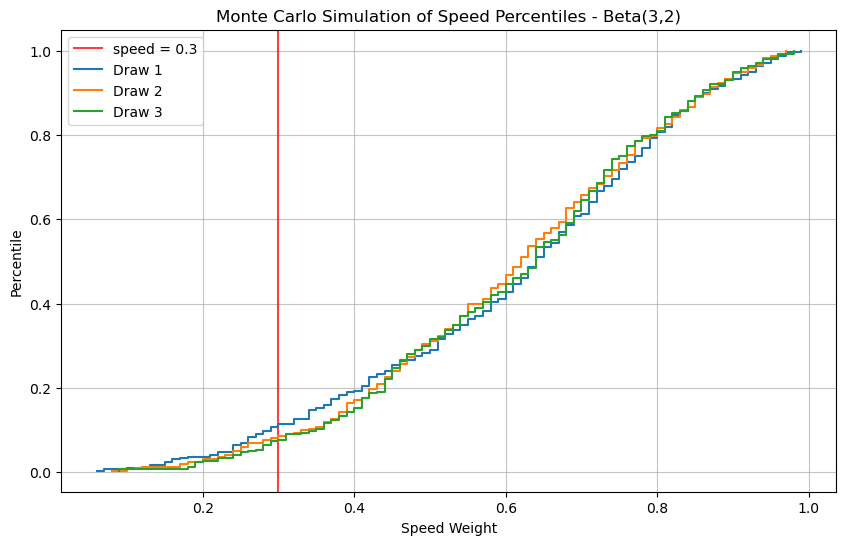

In [175]:
def mc_draws(alpha, beta, path=1, n=1):
    draws = {}
    for i in range(1, 1+path):
        draws[f"draw_{i}"] = beta_draw(alpha, beta, n)
    return pd.DataFrame(draws)

def compute_percentiles(df_draws, speed):
    percentiles = pd.Series([], name='speed_percentile')
    for i in range(df_draws.shape[1]):
        draw = df_draws.iloc[:,i]
        p = np.mean(draw <= speed) * 100
        percentiles = pd.concat([percentiles, pd.Series([p])], ignore_index=True)
    return percentiles

# Example
ex_speed = 0.3
ex_draws = mc_draws(alpha=3, beta=2, path=200, n=300)

# Plot
plt.figure(figsize=(10, 6))
plt.axvline(ex_speed, color='red', label=f'speed = {ex_speed}', alpha=0.75)
for i in range(3):
    data = ex_draws.iloc[:, i]
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.step(sorted_data, cdf, where='post', label=f'Draw {i+1}')
plt.xlabel('Speed Weight')
plt.ylabel('Percentile')
plt.title('Monte Carlo Simulation of Speed Percentiles - Beta(3,2)')
plt.legend()
plt.grid(alpha=0.75)
plt.show()

#### 4.2. Monte Carlo Profit Simulation

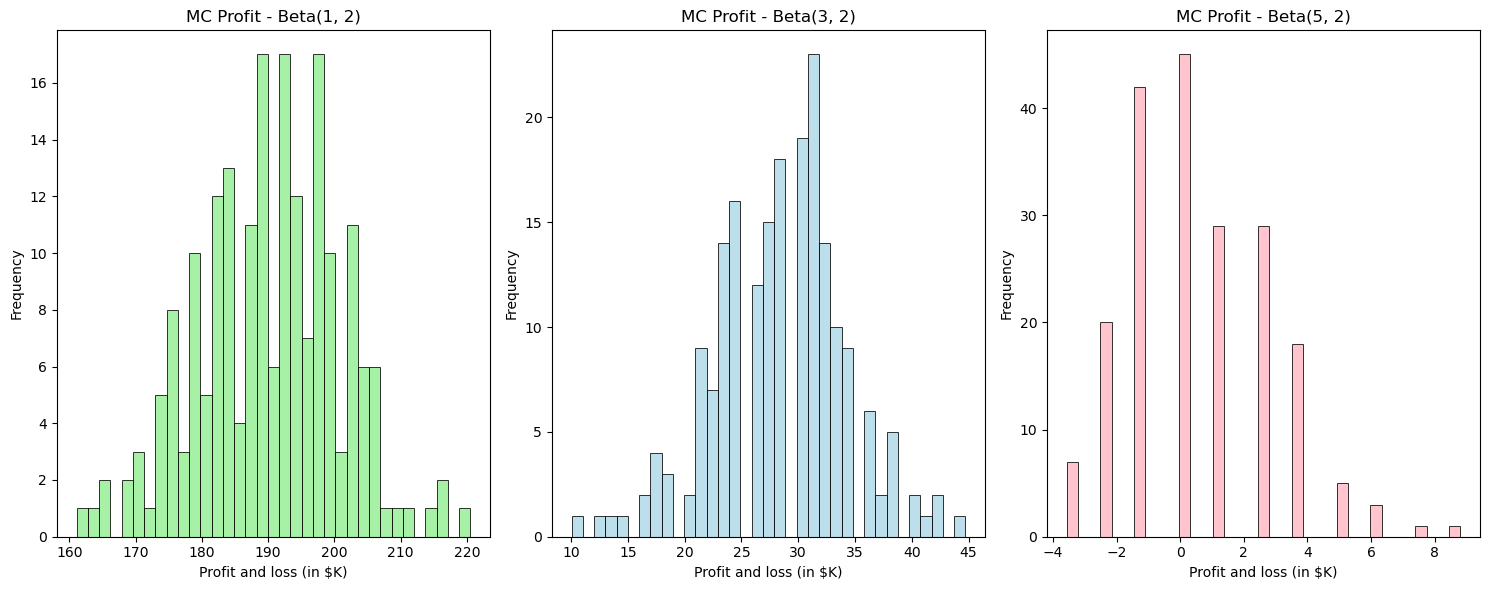

In [176]:
def mc_pnl(alpha, speed):
    draws = mc_draws(alpha, beta=2, path=200, n=300)
    pnl_series = []
    params = split(speed)
    speed_percentiles = compute_percentiles(draws, speed)
    for speed_p in speed_percentiles:
        profit = round(pnl(params, speed_p),0) / 1000
        pnl_series.append(profit)
    return pd.Series(pnl_series, name="pnl")

# plot
alpha_values = [1, 3, 5]
sim_pnl_draws = [mc_pnl(a, ex_speed) for a in alpha_values]
colors = ['lightgreen','lightblue', 'lightpink']
fig, ax = plt.subplots(1, 3, figsize=(15,6))
for i in range(3):
    ax[i].hist(sim_pnl_draws[i], bins=35, color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.7)
    ax[i].set_title(f"MC Profit - Beta({alpha_values[i]}, 2)")
    ax[i].set_xlabel(f"Profit and loss (in $K)")
    ax[i].set_ylabel(f"Frequency")
plt.tight_layout()
plt.show()

### 5. Optimal Allocation with Field Bet Uncertainty

#### 5.1. Optimizing for the 25th Percentile

5.1.1. Profit and Loss Surface

In [177]:
def quantile_surface(X, alpha_range, speed_range):
    surface = np.zeros((len(speed_range), len(alpha_range)))
    for i, speed in enumerate(tqdm(speed_range, desc='Speed')):
        for j, alpha in enumerate(alpha_range):
            pnl_series = mc_pnl(alpha, speed)
            surface[i, j] = np.quantile(pnl_series, X)
    return surface

def maximize_surface(surface, alpha_range, speed_range):
    idx = np.unravel_index(np.argmax(surface), surface.shape)
    best_speed = speed_range[idx[0]]
    best_alpha = alpha_range[idx[1]]
    best_value = surface[idx]
    return best_alpha, best_speed, best_value

# 25th percentile
X = 0.25

# Surface computation
alpha_range = np.arange(1, 5.1, 0.1)
speed_range = np.arange(0.01, 0.91, 0.01)
surface = quantile_surface(X, alpha_range, speed_range)

# Plot
fig = go.Figure(data=[go.Surface(z=surface, x=alpha_range, y=speed_range)])
fig.update_layout(title=f'Surface of the PNL {X}th Percentile',
                  scene=dict(xaxis_title='Alpha', yaxis_title='Speed', zaxis_title='PNL'),
                  autosize=True, height=700, width=1000)
fig.show()

Speed:   0%|          | 0/90 [00:00<?, ?it/s]

5.1.2. Marginal Distribution of Speed

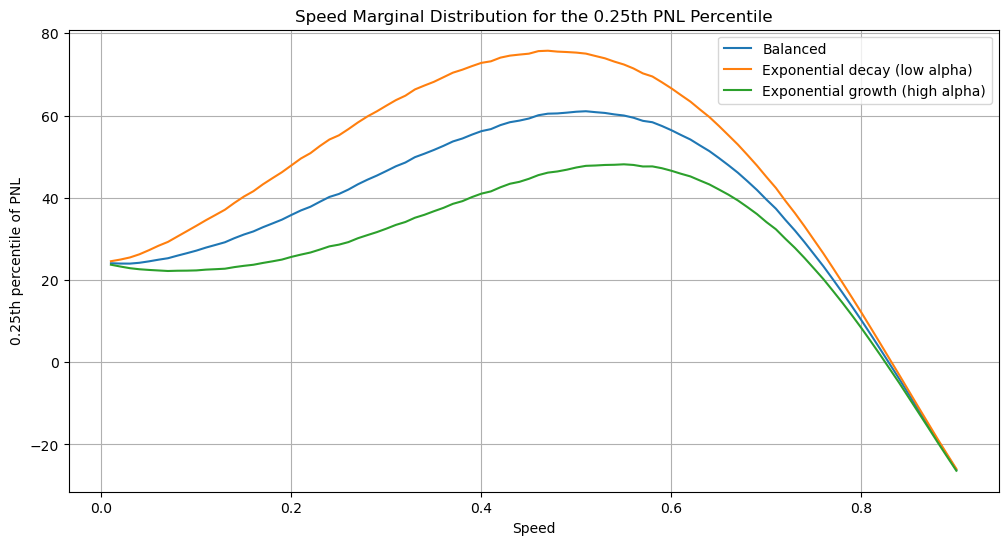

Equal probabilities: max at speed=0.51, percentile 0.25th of PNL=61.05
Exponential decay: max at speed=0.47, percentile 0.25th of PNL=75.77
Exponential growth: max at speed=0.55, percentile 0.25th of PNL=48.14


In [178]:
# Equal probability
alpha_probs_equi = np.ones(len(alpha_range)) / len(alpha_range)

# Exponential Decay
lambda_decay = np.log(3) / (len(alpha_range) - 1)
alpha_probs_decay = np.exp(-lambda_decay * np.arange(len(alpha_range)))
alpha_probs_decay /= alpha_probs_decay.sum()

# Exponential Growth
lambda_growth = np.log(3) / (len(alpha_range) - 1)
alpha_probs_growth = np.exp(lambda_growth * np.arange(len(alpha_range)))
alpha_probs_growth /= alpha_probs_growth.sum()

# Marginals Distribution
marg_equi = np.dot(surface, alpha_probs_equi)
marg_decay = np.dot(surface, alpha_probs_decay)
marg_growth = np.dot(surface, alpha_probs_growth)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(speed_range, marg_equi, label='Balanced')
plt.plot(speed_range, marg_decay, label='Exponential decay (low alpha)')
plt.plot(speed_range, marg_growth, label='Exponential growth (high alpha)')
plt.xlabel('Speed')
plt.ylabel(f'{X}th percentile of PNL')
plt.title(f'Speed Marginal Distribution for the {X}th PNL Percentile')
plt.legend()
plt.grid(True)
plt.show()

# print optimal
for name, marg in zip([
    'Equal probabilities',
    'Exponential decay',
    'Exponential growth'
], [marg_equi, marg_decay, marg_growth]):
    idx_max = np.argmax(marg)
    best_speed = speed_range[idx_max]
    best_pnl = marg[idx_max]
    print(f"{name}: max at speed={best_speed:.2f}, percentile {X}th of PNL={best_pnl:.2f}")


#### 5.2. Optimizing for the Median

5.2.1. Profit and Loss Surface

In [179]:
X = 0.5

# Surface
surface2 = quantile_surface(X, alpha_range, speed_range)

# Plot
fig = go.Figure(data=[go.Surface(z=surface2, x=alpha_range, y=speed_range)])
fig.update_layout(title=f'Surface of the PNL {X}th Percentile',
                  scene=dict(xaxis_title='Alpha', yaxis_title='Speed', zaxis_title='PNL'),
                  autosize=True, height=700, width=1000)
fig.show()

Speed:   0%|          | 0/90 [00:00<?, ?it/s]

5.2.2. Marginal Distribution of Speed

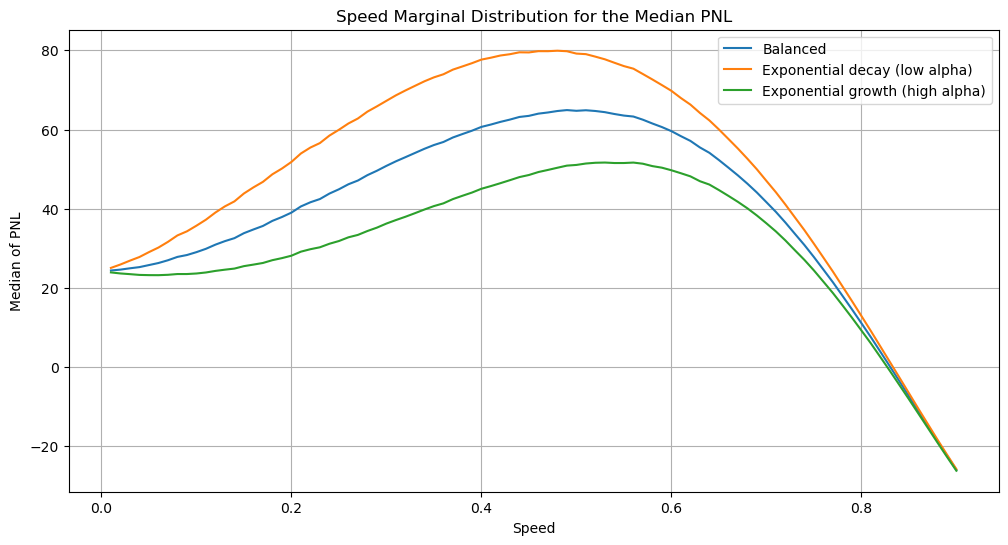

Equal probabilities: max at speed=0.49, median of PNL=64.91
Exponential decay: max at speed=0.48, median of PNL=79.90
Exponential growth: max at speed=0.53, median of PNL=51.66


In [180]:
# Marginals
marg_equi = np.dot(surface2, alpha_probs_equi)
marg_decay = np.dot(surface2, alpha_probs_decay)
marg_growth = np.dot(surface2, alpha_probs_growth)

plt.figure(figsize=(12, 6))
plt.plot(speed_range, marg_equi, label='Balanced')
plt.plot(speed_range, marg_decay, label='Exponential decay (low alpha)')
plt.plot(speed_range, marg_growth, label='Exponential growth (high alpha)')
plt.xlabel('Speed')
plt.ylabel(f'Median of PNL')
plt.title(f'Speed Marginal Distribution for the Median PNL')
plt.legend()
plt.grid(True)
plt.show()

# Print optimal
for name, marg in zip([
    'Equal probabilities',
    'Exponential decay',
    'Exponential growth'
], [marg_equi, marg_decay, marg_growth]):
    idx_max = np.argmax(marg)
    best_speed = speed_range[idx_max]
    best_pnl = marg[idx_max]
    print(f"{name}: max at speed={best_speed:.2f}, median of PNL={best_pnl:.2f}")


#### 6. Optimal Allocation Performance Simulation

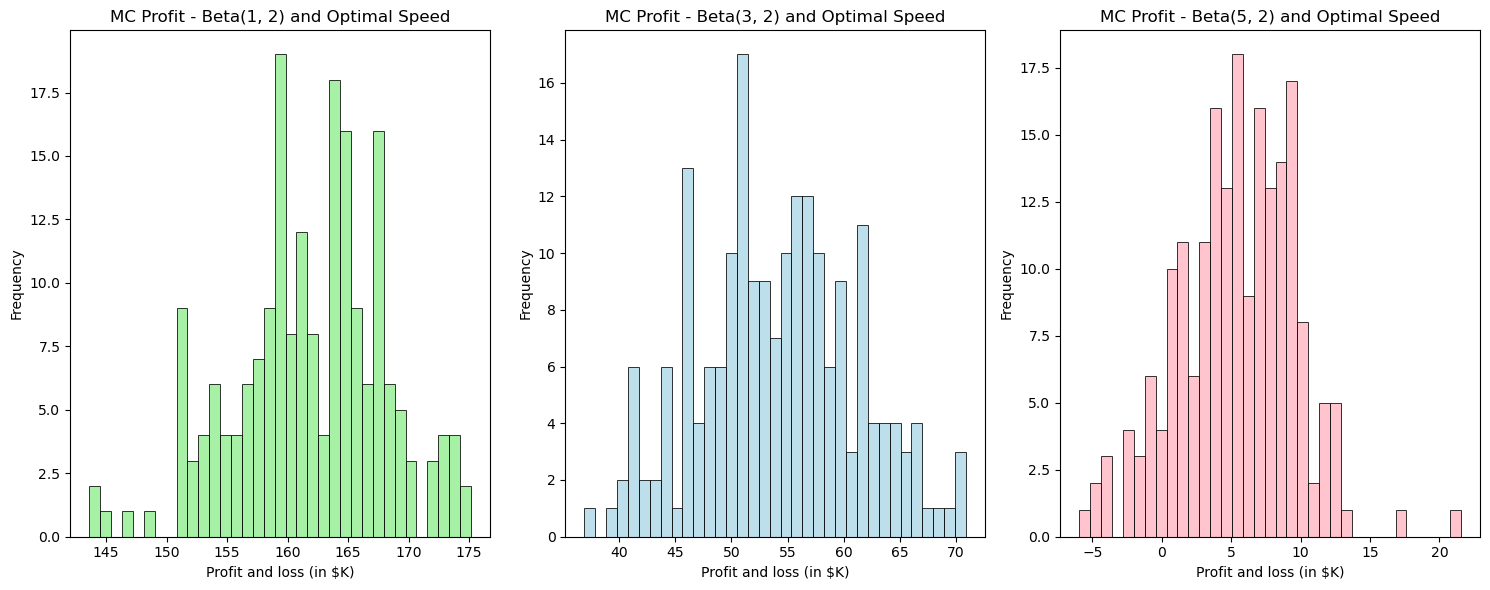

In [181]:

# plot
optimal_speed = speed_range[np.argmax(marg_equi)]
alpha_values = [1, 3, 5]
sim_pnl_draws = [mc_pnl(a, optimal_speed) for a in alpha_values]
colors = ['lightgreen','lightblue', 'lightpink']
fig, ax = plt.subplots(1, 3, figsize=(15,6))
for i in range(3):
    ax[i].hist(sim_pnl_draws[i], bins=35, color=colors[i], alpha=0.8, edgecolor='black', linewidth=0.7)
    ax[i].set_title(f"MC Profit - Beta({alpha_values[i]}, 2) and Optimal Speed")
    ax[i].set_xlabel(f"Profit and loss (in $K)")
    ax[i].set_ylabel(f"Frequency")
plt.tight_layout()
plt.show()